In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
def f(x):
    return x**3 - x - 2


a = 1
b = 2
tolerance = 0.000001
max_iterations = 100

iterations = []
midpoints = []
function_values = []
absolute_errors = []
relative_errors = []

previous_midpoint = None

for i in range(1, max_iterations + 1):

    c = (a + b) / 2
    fc = f(c)

    if previous_midpoint is None:
        absolute_error = np.nan
        relative_error = np.nan
    else:
        absolute_error = abs(c - previous_midpoint)
        relative_error = absolute_error / abs(c)

    iterations.append(i)
    midpoints.append(c)
    function_values.append(fc)
    absolute_errors.append(absolute_error)
    relative_errors.append(relative_error)

    if f(a) * fc < 0:
        b = c
    else:
        a = c

    if previous_midpoint is not None and absolute_error < tolerance:
        break

    previous_midpoint = c

result = pd.DataFrame({
    "Iteration": iterations,
    "Midpoint": midpoints,
    "f(c)": function_values,
    "Absolute Error": absolute_errors,
    "Relative Error": relative_errors
})

print(result.to_string(index=False))

print("\nApproximate Root =", midpoints[-1])
print("Number of Iterations =", len(iterations))

 Iteration  Midpoint      f(c)  Absolute Error  Relative Error
         1  1.500000 -0.125000             NaN             NaN
         2  1.750000  1.609375    2.500000e-01    1.428571e-01
         3  1.625000  0.666016    1.250000e-01    7.692308e-02
         4  1.562500  0.252197    6.250000e-02    4.000000e-02
         5  1.531250  0.059113    3.125000e-02    2.040816e-02
         6  1.515625 -0.034054    1.562500e-02    1.030928e-02
         7  1.523438  0.012250    7.812500e-03    5.128205e-03
         8  1.519531 -0.010971    3.906250e-03    2.570694e-03
         9  1.521484  0.000622    1.953125e-03    1.283697e-03
        10  1.520508 -0.005179    9.765625e-04    6.422608e-04
        11  1.520996 -0.002279    4.882812e-04    3.210273e-04
        12  1.521240 -0.000829    2.441406e-04    1.604879e-04
        13  1.521362 -0.000103    1.220703e-04    8.023750e-05
        14  1.521423  0.000259    6.103516e-05    4.011714e-05
        15  1.521393  0.000078    3.051758e-05    2.005

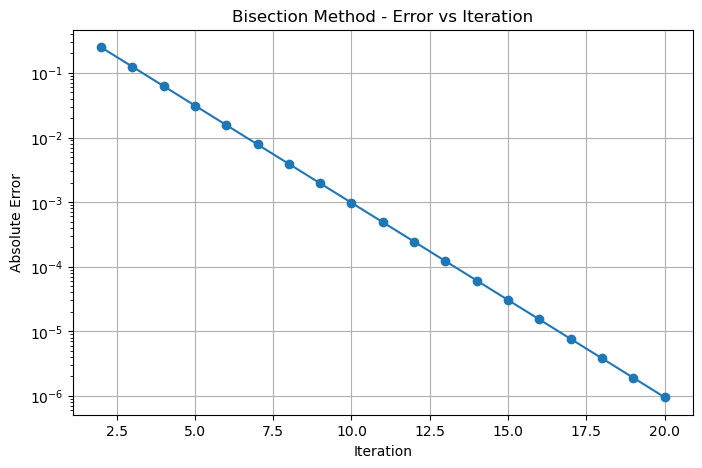

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    iterations[1:],
    absolute_errors[1:],
    marker='o'
)

plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Absolute Error")
plt.title("Bisection Method - Error vs Iteration")
plt.grid(True)

plt.show()

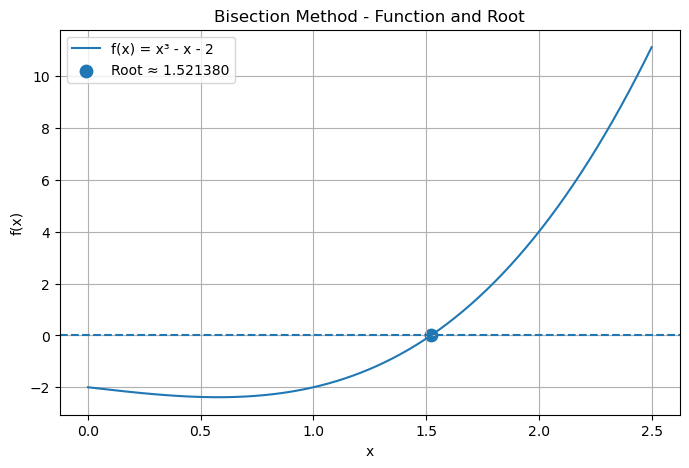

In [6]:
x = np.linspace(0, 2.5, 500)
y = f(x)

root = midpoints[-1]

plt.figure(figsize=(8, 5))

plt.plot(x, y, label="f(x) = x³ - x - 2")
plt.axhline(0, linestyle='--')
plt.scatter(root, f(root), s=80, label=f"Root ≈ {root:.6f}")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Bisection Method - Function and Root")
plt.legend()
plt.grid(True)

plt.show()